In [ ]:
import torch
import pandas as pd 
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import faiss

from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score

In [31]:
embeds = torch.load("../../data/embeddings/raw_embeds.pt", weights_only=False)

conn = sqlite3.connect("../../data/sql/metadata.db")

meta = pd.read_sql_query("SELECT * FROM meta", conn)

conn.close()

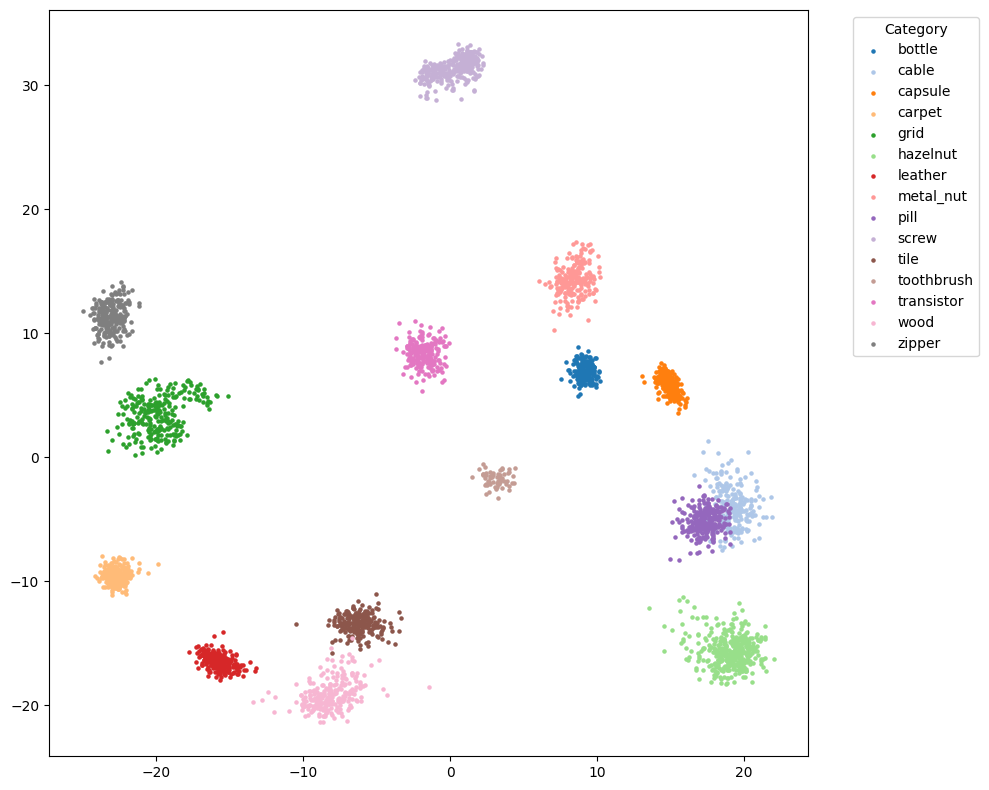

In [32]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeds)

categories = sorted(meta["category"].unique())

colors = list(plt.cm.tab20.colors[:len(categories)])

plt.figure(figsize=(10, 8))

for color, category in zip(colors, categories):
    mask = (
        (meta["category"] == category) & (meta["split"] == "train")
    )

    plt.scatter(
        emb_2d[mask, 0],
        emb_2d[mask, 1],
        s=5,
        color=color,
        label=category
    )

plt.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

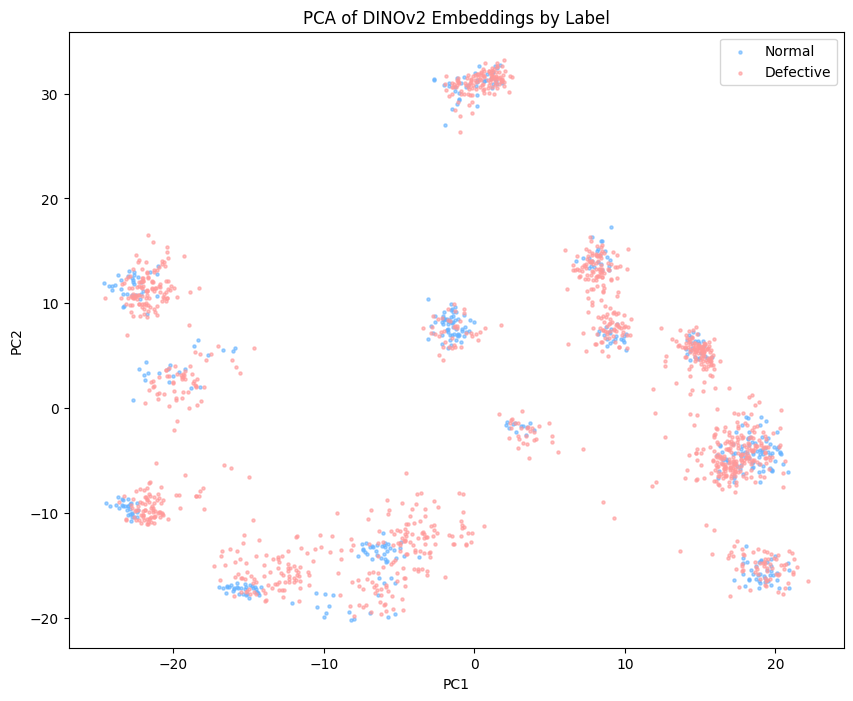

In [33]:
plt.figure(figsize=(10, 8))

for label, name, color in [
    (0, "Normal", "#66b3ff"),
    (1, "Defective", "#ff9999")
]:
    
    mask = (
        (meta["split"] == "test") & (meta["label"] == label)
    )

    plt.scatter(
        emb_2d[mask, 0],
        emb_2d[mask, 1],
        s=5,
        alpha=0.6,
        color=color,
        label=name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of DINOv2 Embeddings by Label")

plt.legend()
plt.show()

In [46]:
results = {}

for category in meta["category"].unique():
    train_embeds = embeds[
        (meta["category"] == category)
        & (meta["split"] == "train")
    ]

    centroid = train_embeds.mean(axis=0)

    covariance = np.cov(train_embeds.T)
    
    cov_inv = np.linalg.inv(covariance)

    test_embeds = embeds[
        (meta["category"] == category)
        & (meta["split"] == "test")
    ]

    test_labels = meta[
        (meta["category"] == category)
        & (meta["split"] == "test")
    ]["label"]

    diff = test_embeds - centroid
    cen_scores = np.linalg.norm(diff, axis=1)
    covariance += np.eye(covariance.shape[0]) * 1e-6

    cov_inv = np.linalg.pinv(covariance)
    
    index = faiss.IndexFlatL2(
        train_embeds.shape[1]
    )

    index.add(
        train_embeds.astype("float32")
    )

    D, I = index.search(
        test_embeds.astype("float32"),
        k=5
    )

    nn_scores = D[:, 0]
    avg_nn_scores = D.mean(axis=1)

    mal_scores = np.sqrt(
        np.einsum(
            "ij, jk, ik->i",
            diff,
            cov_inv,
            diff
        )
    )

    results[category] = {
        "train": train_embeds,
        "test": test_embeds,
        "centroid": centroid,
        "cen_scores": cen_scores,
        "nn_scores": nn_scores,
        "avg_nn_scores": avg_nn_scores,
        "mal_scores": mal_scores,
        "labels": test_labels
    }


In [35]:
results

{'bottle': {'train': array([[ 1.9483376 , -0.35311538,  0.64744604, ..., -1.7477032 ,
          -1.0832971 ,  1.6305344 ],
         [ 1.9681519 , -0.10568309,  1.1683798 , ..., -1.9673982 ,
          -1.2570024 ,  2.1852753 ],
         [ 2.1140132 , -0.62745446,  0.536631  , ..., -1.685824  ,
          -1.4440172 ,  1.6715763 ],
         ...,
         [ 2.9943686 , -0.26756844,  2.078786  , ..., -2.3279102 ,
          -1.822237  ,  1.9411821 ],
         [ 2.1522174 , -0.5515114 ,  0.79365814, ..., -1.5554439 ,
          -1.953998  ,  1.6810272 ],
         [ 3.0976717 , -0.45597112,  1.7099036 , ..., -1.882748  ,
          -1.3997946 ,  1.6068869 ]], shape=(209, 384), dtype=float32),
  'test': array([[ 1.8924185 , -0.05745453,  1.3529111 , ...,  0.19874798,
           0.9754317 ,  1.7291784 ],
         [ 2.8398328 , -0.37633005,  2.1186209 , ..., -0.25865784,
          -0.27790484,  1.1095908 ],
         [ 2.5701644 , -0.79111946,  1.5664188 , ...,  0.17525215,
          -1.2443933 ,  0

In [ ]:
def score_plots(score_type: str = "nn_scores"):
    aurocs = {}
    auprcs = {}

    _, axes = plt.subplots(3, 5, figsize=(30, 20))

    axes = axes.flatten()

    for i, category in enumerate(results.keys()):
        ax = axes[i]

        scores = results[category][score_type]
        labels = results[category]["labels"]

        auc = roc_auc_score(labels, scores)
        prc = average_precision_score(labels, scores)

        aurocs[category] = auc
        auprcs[category] = prc

        ax.hist(
            scores[labels == 0],
            alpha=0.5,
            label="Normal"
        )

        ax.hist(
            scores[labels == 1],
            alpha = 0.5,
            label="Defective"
        )

        ax.set_title(f"{category}\nAUROC = {auc:.4f}")
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
        ax.legend()

    plt.show()
    return aurocs

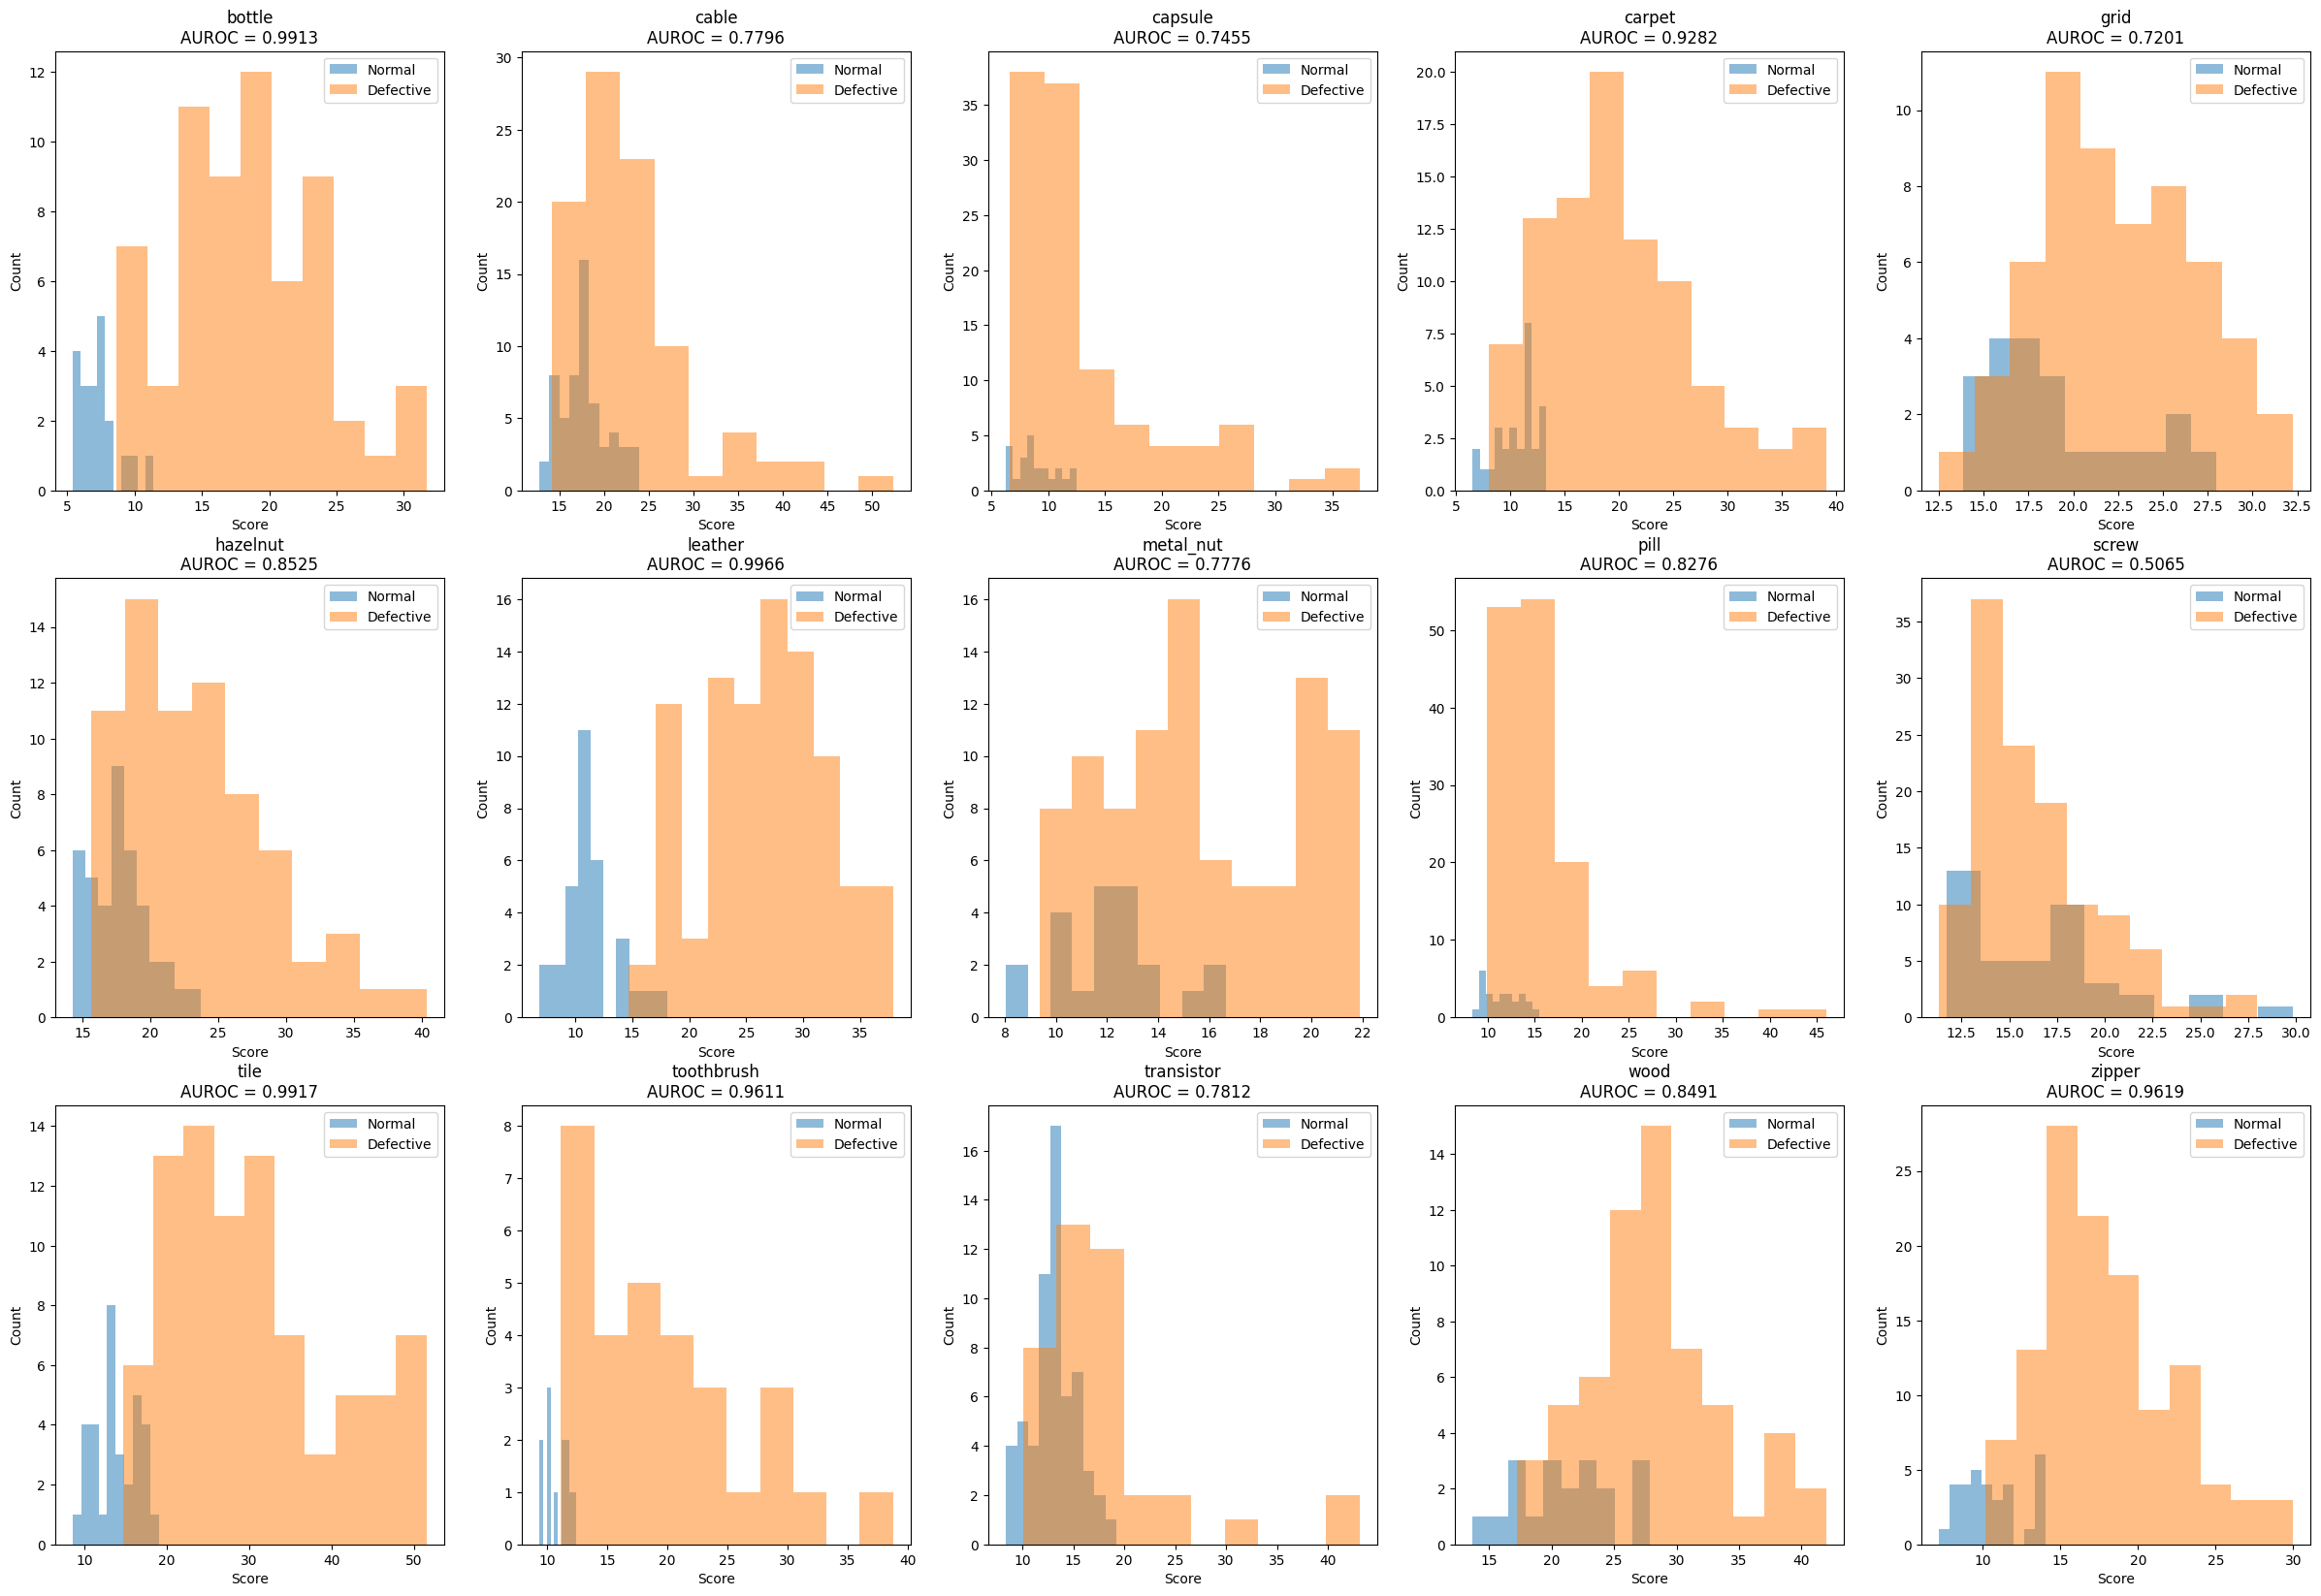

In [37]:
cen_aurocs = score_plots(score_type="cen_scores")

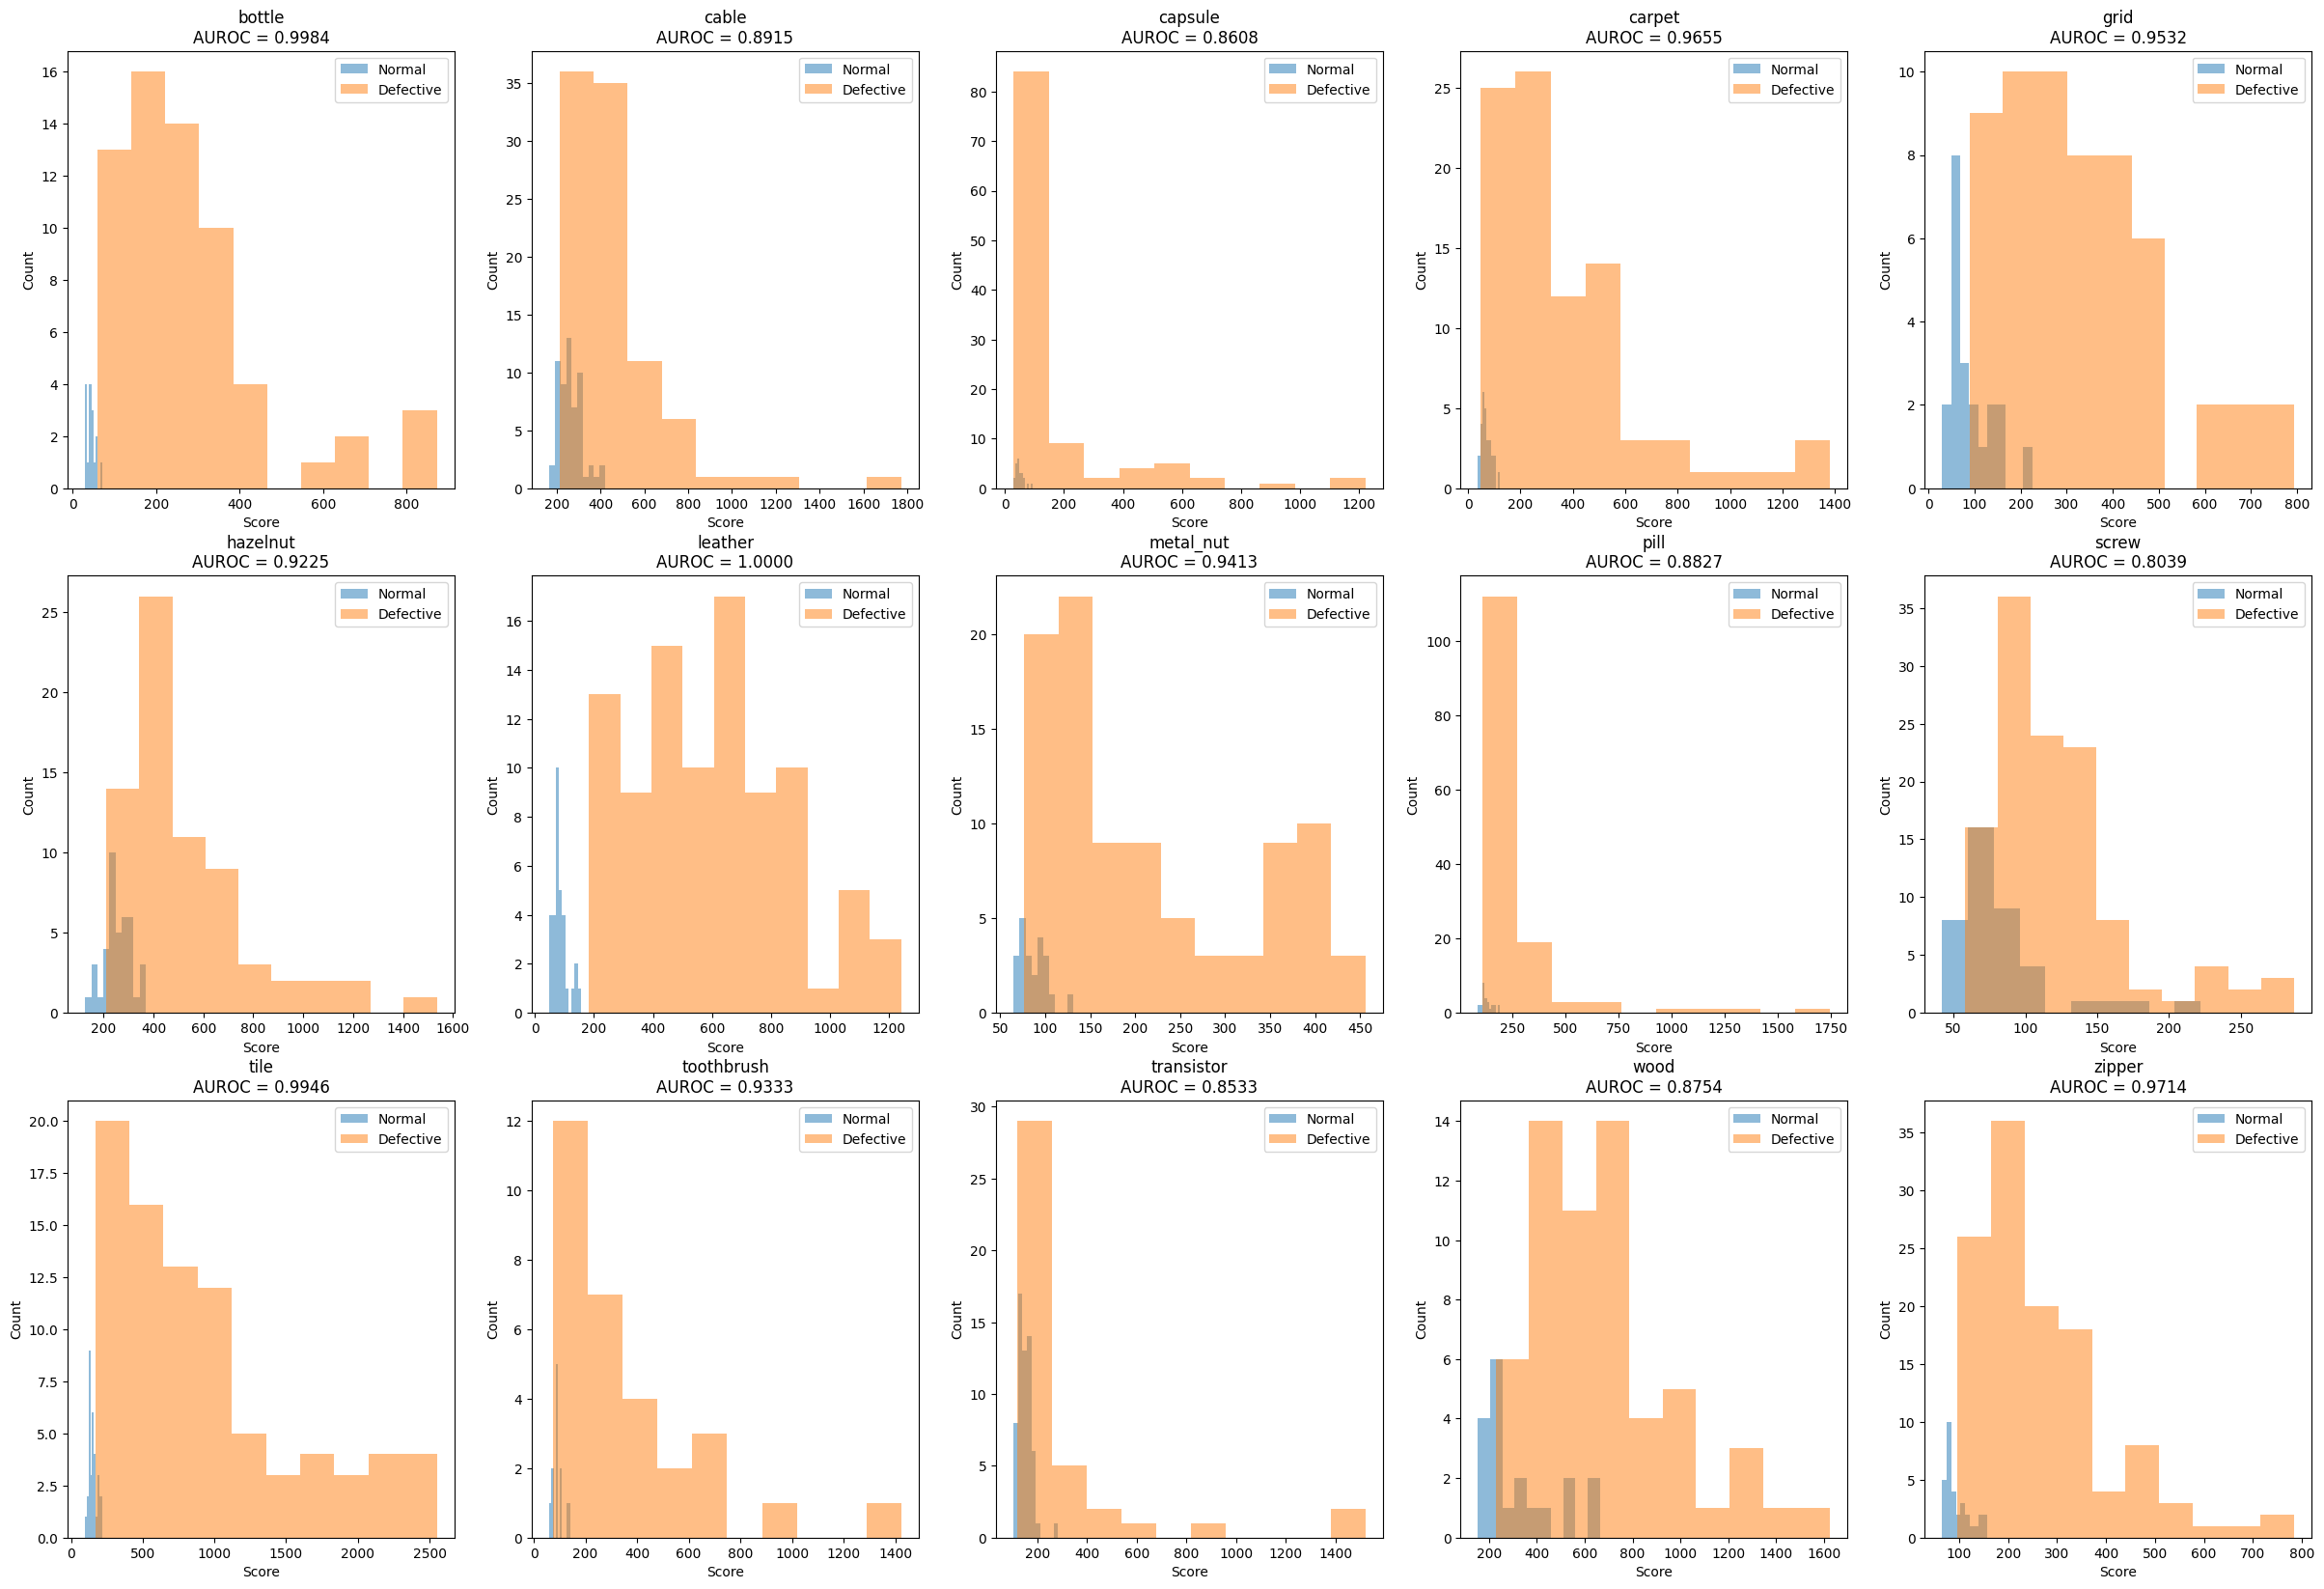

In [40]:
nn_aurocs = score_plots(score_type="nn_scores")

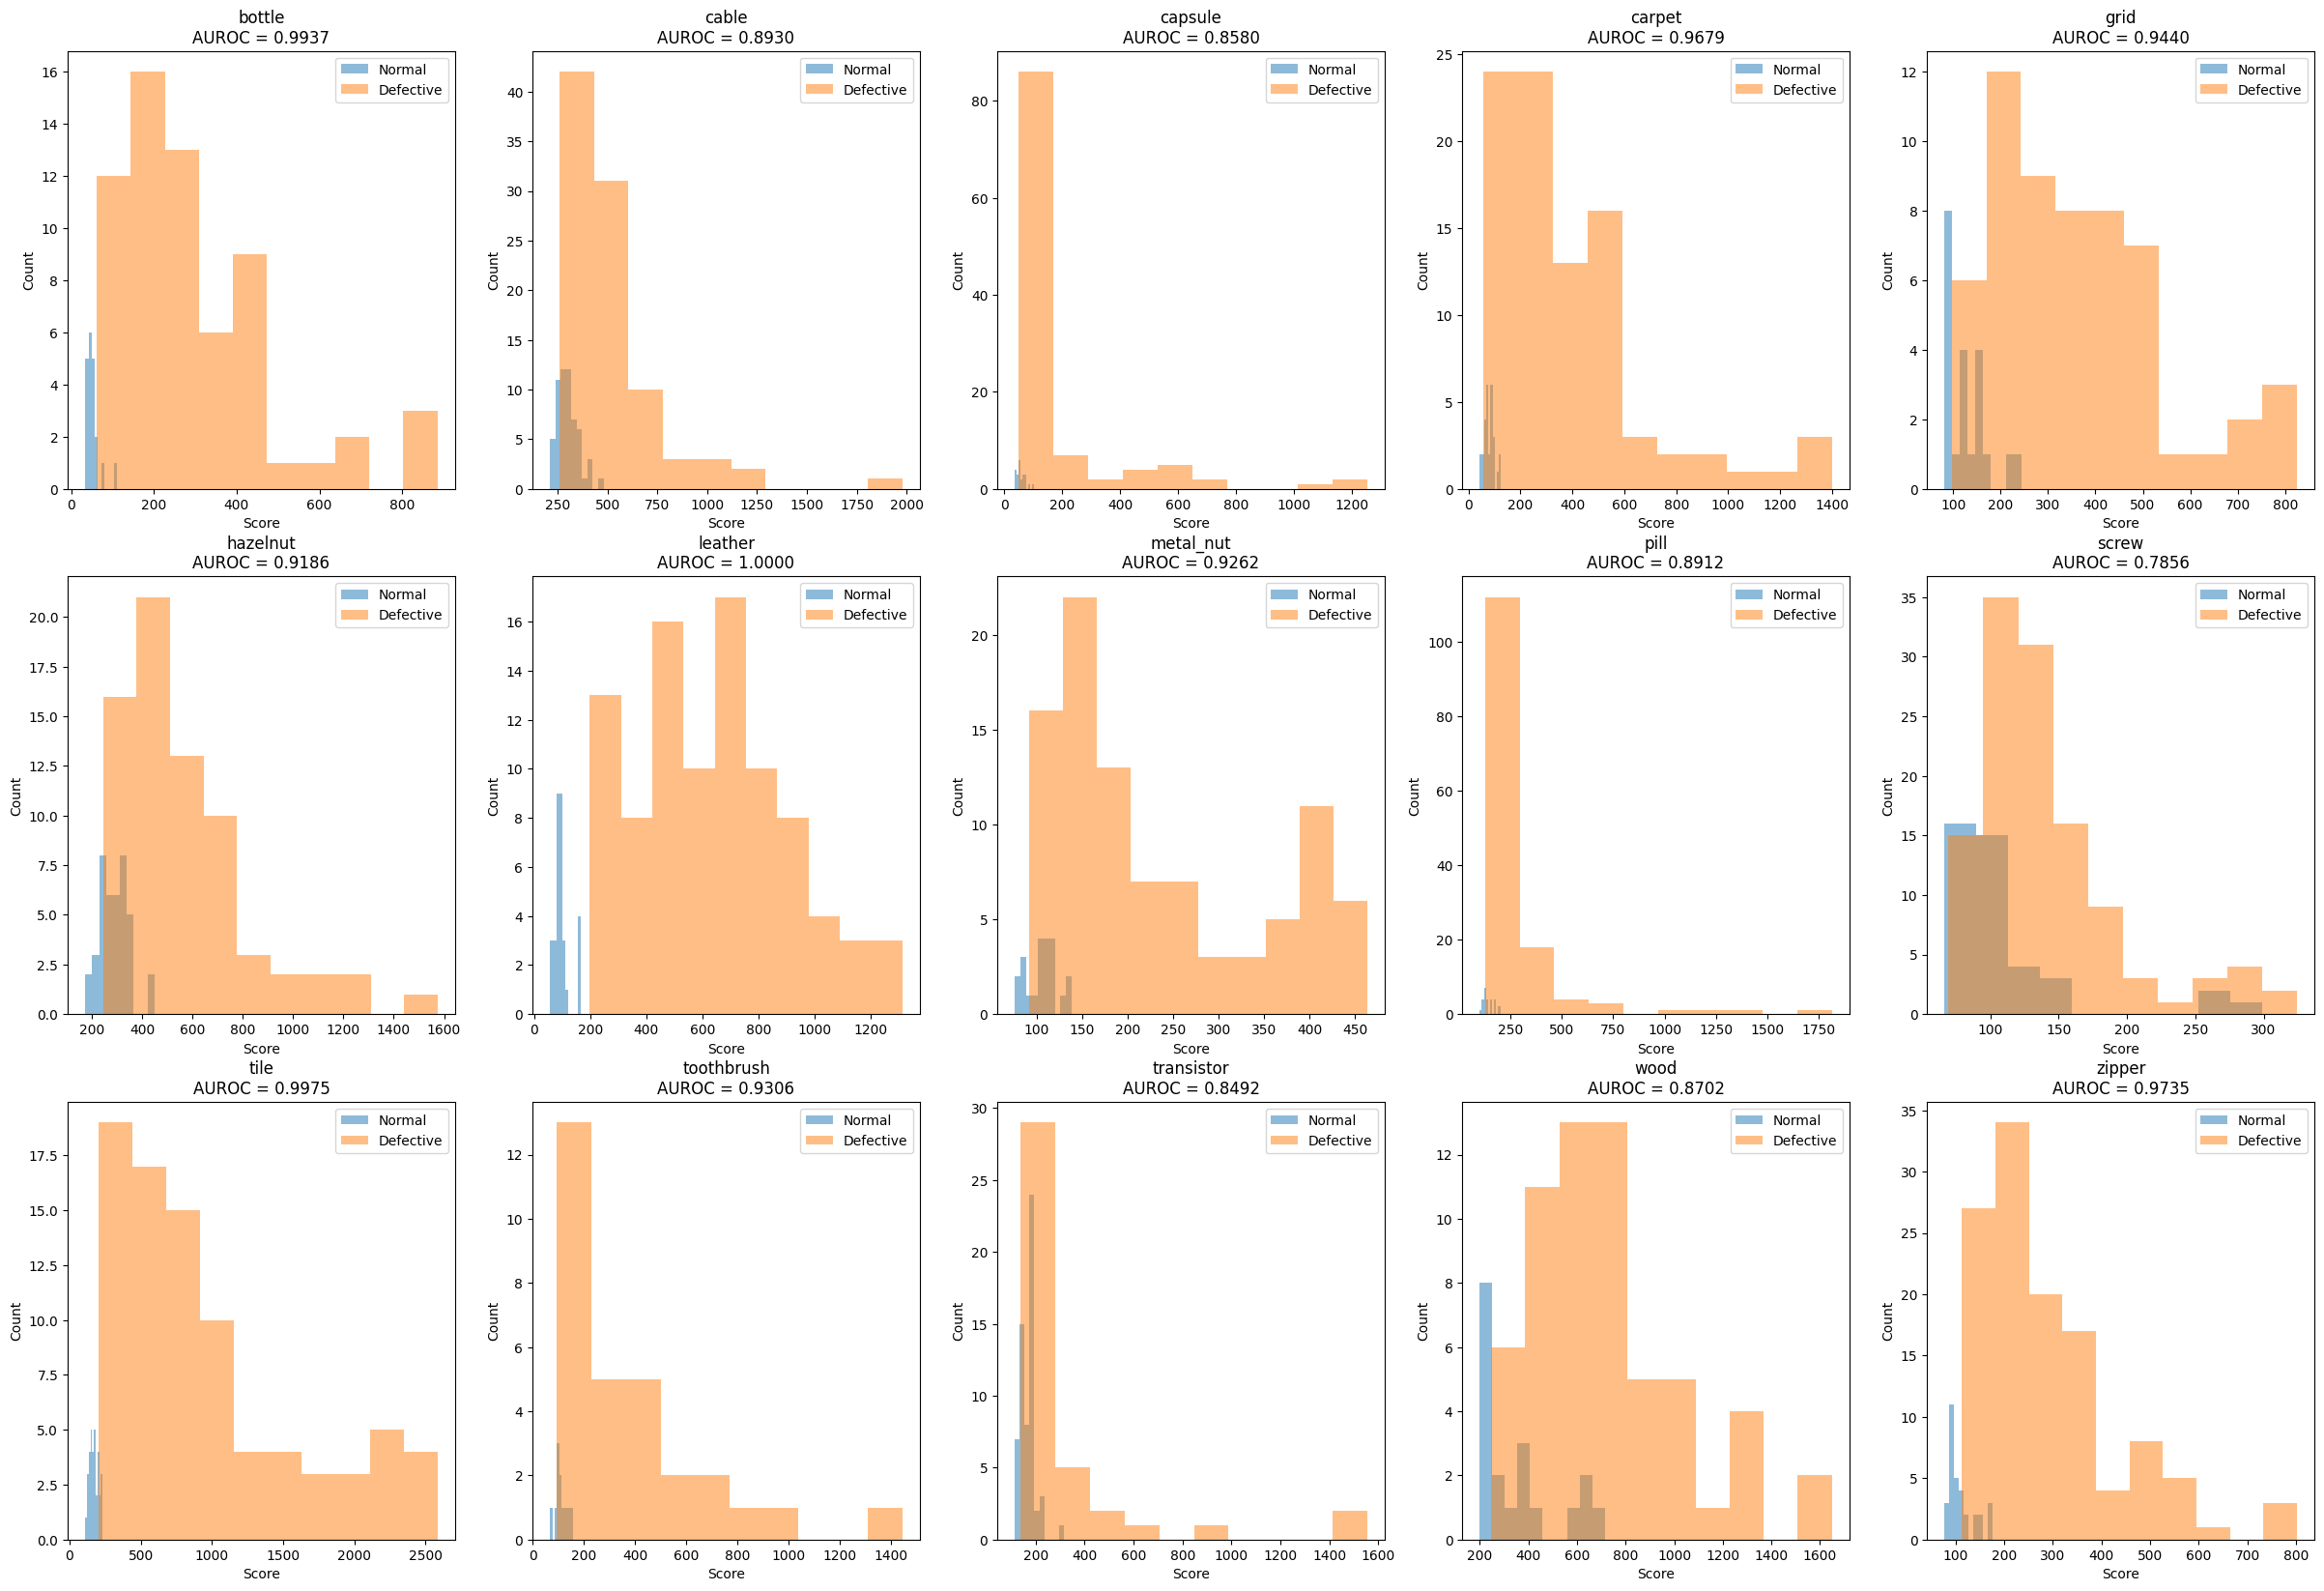

In [41]:
avg_nn_aurocs = score_plots(score_type="avg_nn_scores")

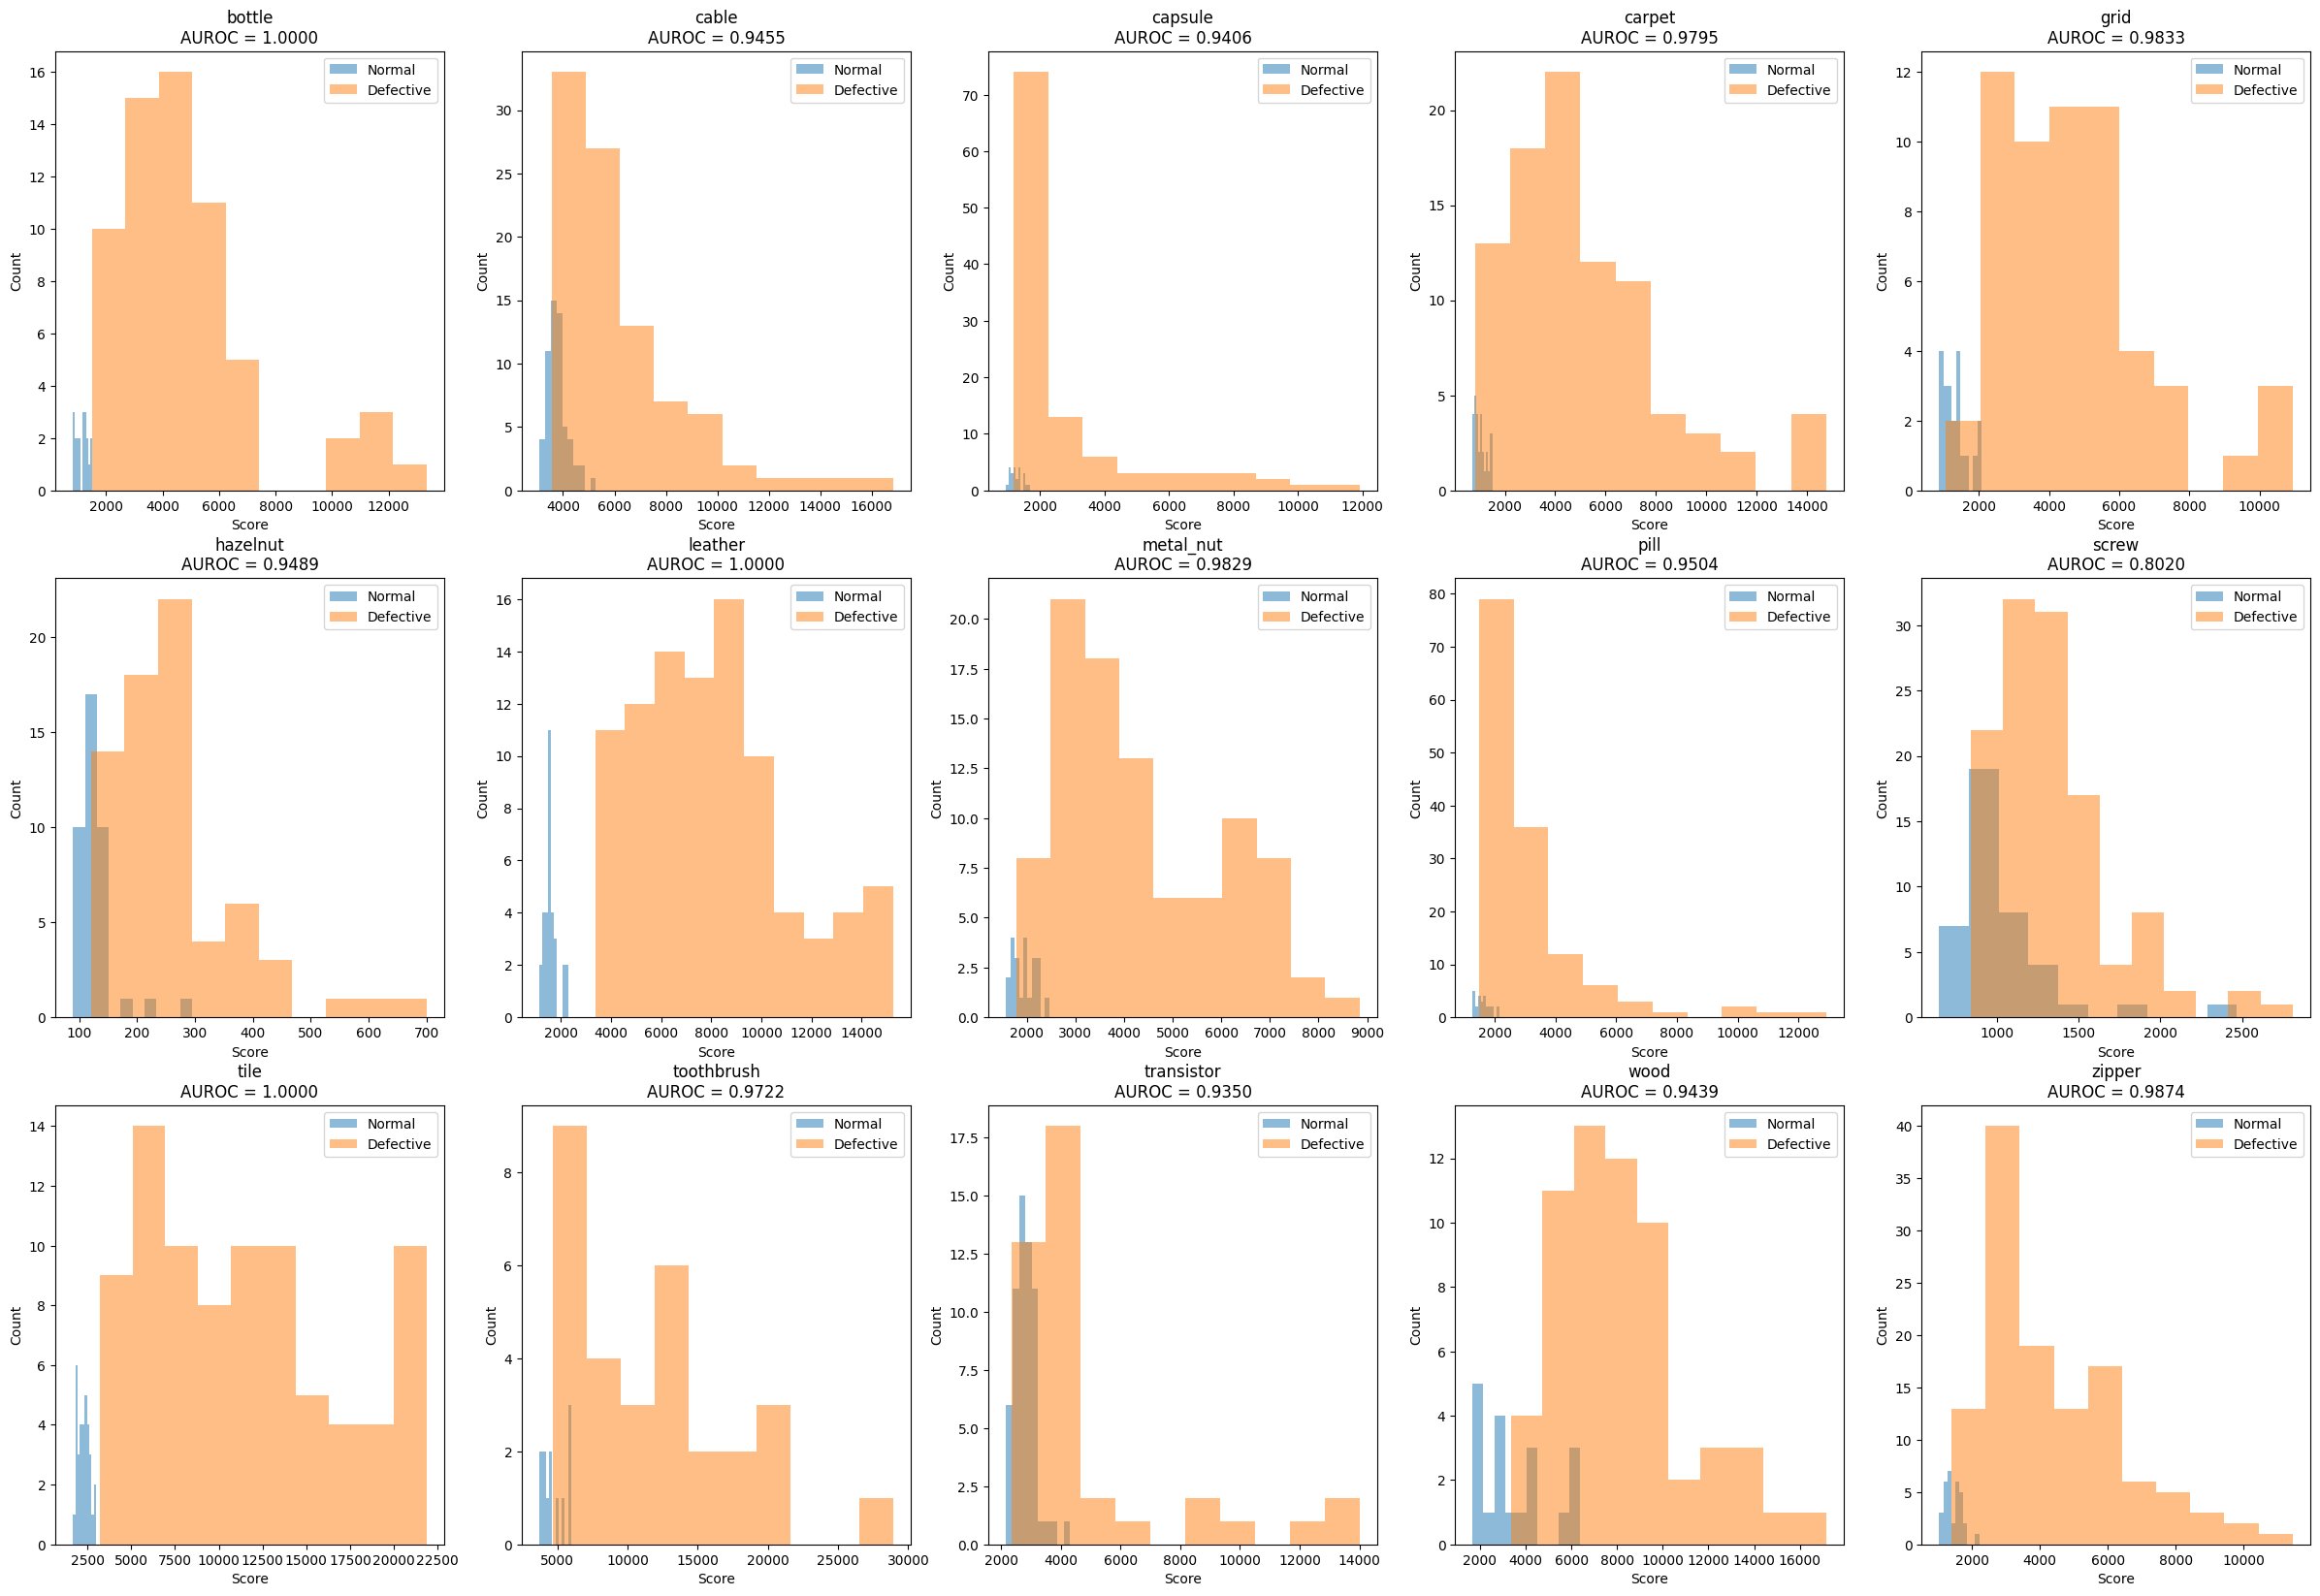

In [47]:
mal_aurocs = score_plots(score_type="mal_scores")

In [49]:
df_aucs = pd.DataFrame()

df_aucs["cen_aurocs"] = cen_aurocs
df_aucs["nn_aurocs"] = nn_aurocs
df_aucs["avg_nn_aurocs"] = avg_nn_aurocs
df_aucs["mal_aurocs"] = mal_aurocs

df_aucs

,cen_aurocs,nn_aurocs,avg_nn_aurocs,mal_aurocs
bottle,0.991270,0.998413,0.993651,1.000000
cable,0.779610,0.891492,0.892991,0.945465
capsule,0.745513,0.860790,0.857998,0.940566
carpet,0.928170,0.965490,0.967897,0.979535
grid,0.720134,0.953216,0.944027,0.983292
hazelnut,0.852500,0.922500,0.918571,0.948929
leather,0.996603,1.000000,1.000000,1.000000
metal_nut,0.777615,0.941349,0.926197,0.982893
pill,0.827605,0.882706,0.891162,0.950355
screw,0.506456,0.803853,0.785612,0.802009


In [50]:
df_auc_stats = pd.DataFrame({
    "mean": df_aucs.mean(),
    "median": df_aucs.median(),
    "std": df_aucs.std(),
    "min_cat": df_aucs.idxmin(),
    "min": df_aucs.min(),
    "max_cat": df_aucs.idxmax(),
    "max": df_aucs.max()
})

df_auc_stats

,mean,median,std,min_cat,min,max_cat,max
cen_aurocs,0.844706,0.849123,0.134517,screw,0.506456,leather,0.996603
nn_aurocs,0.923192,0.933333,0.059786,screw,0.803853,leather,1.000000
avg_nn_aurocs,0.919930,0.926197,0.062493,screw,0.785612,leather,1.000000
mal_aurocs,0.958101,0.972222,0.049096,screw,0.802009,bottle,1.000000
